# LogisticRegression — Feature Selection

**Method:** L1 Regularization Path (Lasso) with cross-validated stability analysis.

**Why L1 instead of forward selection?**
- Forward selection is O(N²) — with 60 features, that's 1,830 model fits on a single split
- L1 regularization naturally performs feature selection by driving coefficients to exactly zero
- It handles correlated features gracefully — from a group of correlated features, L1 picks one and zeros the others
- Combined with cross-validation, it gives reliable feature importance that doesn't overfit to one split

**Pipeline:**
1. **Decorrelation**: collapse redundant features (Spearman clustering, |ρ| > 0.7)
2. **L1 path**: scan regularization strength C with GroupKFold(5) cross-validation
3. **Stability analysis**: only keep features selected in ≥60% of folds

**Evaluation:** GroupKFold(n_splits=5) grouped by candle_id — no data leakage between candles.


In [22]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json as _json
import random
import warnings
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from feature_utils import (
    decorrelate_features,
    feature_stability_report,
    plot_correlation_matrix,
    plot_stability,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")

## 1. Load data

In [23]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(_json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

print(f"Features: {len(all_feat_cols)}")
print(f"Candles: {df['candle_id'].nunique()}")
print(f"Rows: {len(df):,}")
print(f"UP rate: {df['target'].mean() * 100:.1f}%")

Features: 60
Candles: 4565
Rows: 216,695
UP rate: 51.2%


## 2. Stage 1: Decorrelation

Many features are highly correlated — especially the price-proxy features (`up_risk_reward`,
`down_risk_reward`, `rr_spread`, `up_implied_probability`, etc.) which all encode
"which side is the market favorite."

Correlated features cause problems:
- **Inflated importance**: models split credit between redundant features
- **Unstable selection**: which correlated feature gets picked varies by random split
- **Crowding out**: redundant price features fill the top-N, preventing technical indicators from being selected

We fix this by clustering features with Spearman |ρ| > 0.7 and keeping only the cluster
representative with highest mutual information with the target.


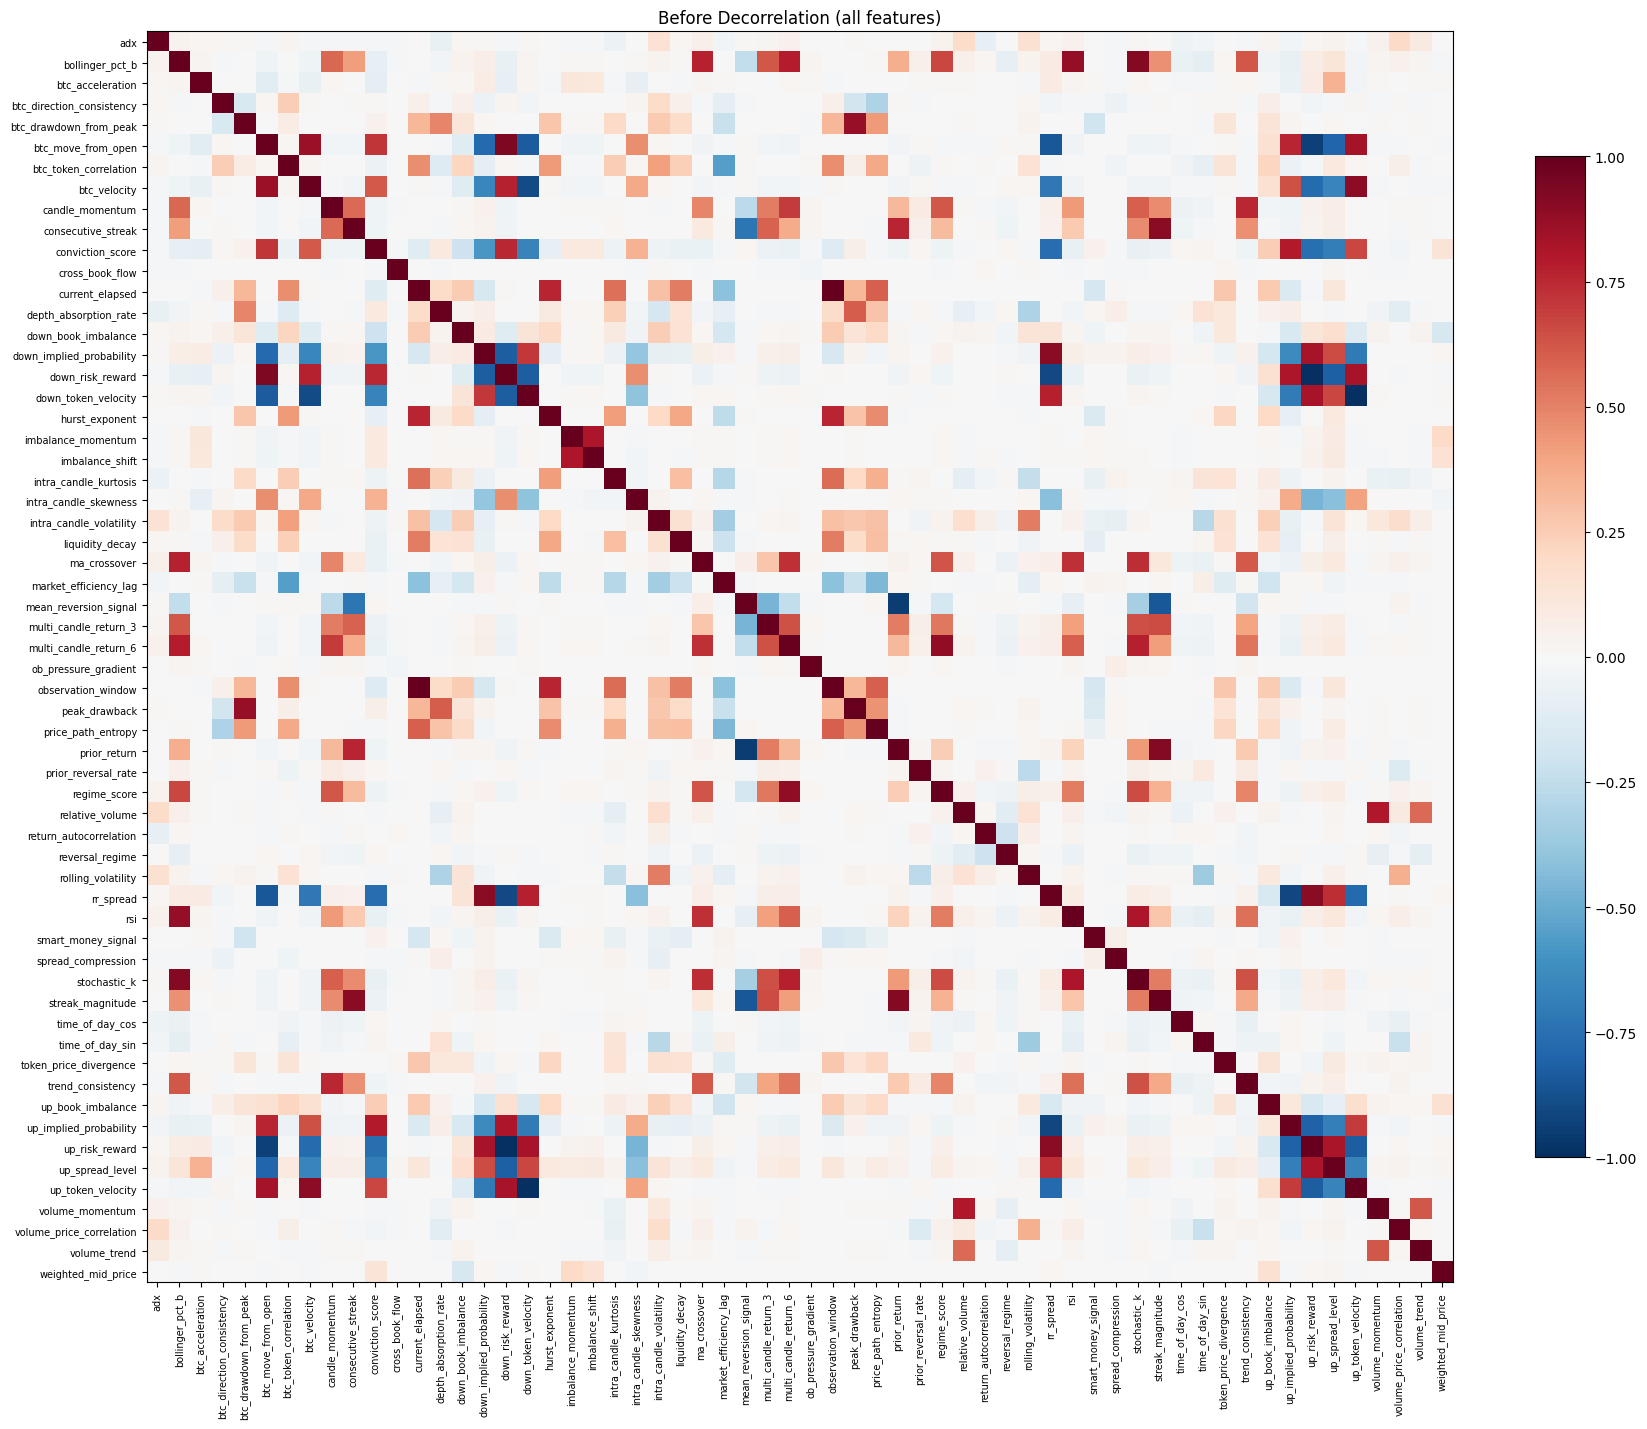


Before: 60 features
After:  37 features (23 dropped)

Clusters with >1 member (collapsed):
  up_risk_reward (MI=0.2088) <- kept from 11 features
    dropped: ['btc_move_from_open', 'btc_velocity', 'conviction_score', 'down_implied_probability', 'down_risk_reward', 'down_token_velocity', 'rr_spread', 'up_implied_probability', 'up_spread_level', 'up_token_velocity']
  bollinger_pct_b (MI=0.6929) <- kept from 4 features
    dropped: ['ma_crossover', 'rsi', 'stochastic_k']
  streak_magnitude (MI=0.6929) <- kept from 4 features
    dropped: ['consecutive_streak', 'mean_reversion_signal', 'prior_return']
  hurst_exponent (MI=0.0002) <- kept from 3 features
    dropped: ['current_elapsed', 'observation_window']
  candle_momentum (MI=0.0090) <- kept from 2 features
    dropped: ['trend_consistency']
  multi_candle_return_6 (MI=0.6929) <- kept from 2 features
    dropped: ['regime_score']
  imbalance_momentum (MI=0.0389) <- kept from 2 features
    dropped: ['imbalance_shift']
  peak_drawback 

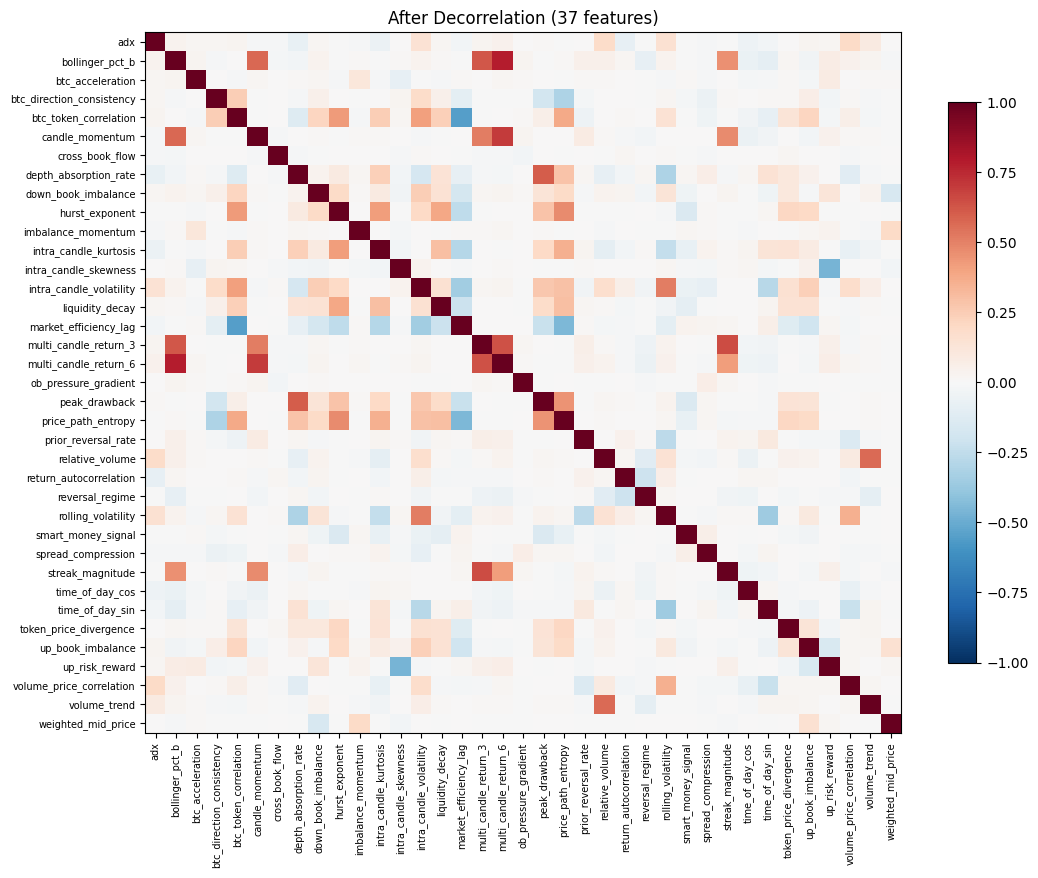

In [24]:
# Show correlation before decorrelation
plot_correlation_matrix(df, all_feat_cols, "Before Decorrelation (all features)")

# Decorrelate
decorr_features, cluster_info = decorrelate_features(
    df,
    all_feat_cols,
    df["target"].values,
    threshold=0.7,
)

print(f"\nBefore: {len(all_feat_cols)} features")
print(f"After:  {len(decorr_features)} features ({len(all_feat_cols) - len(decorr_features)} dropped)")
print("\nClusters with >1 member (collapsed):")
for feat, info in sorted(cluster_info.items(), key=lambda x: -x[1]["cluster_size"]):
    if info["cluster_size"] > 1:
        print(f"  {feat} (MI={info['mutual_info']:.4f}) <- kept from {info['cluster_size']} features")
        print(f"    dropped: {info['dropped']}")

# Show correlation after
plot_correlation_matrix(df, decorr_features, f"After Decorrelation ({len(decorr_features)} features)")

## 3. Stage 2: L1 Regularization Path

L1 (Lasso) regularization adds a penalty proportional to the absolute value of coefficients.
As we increase regularization strength (lower C), more coefficients are driven to exactly zero.

We use **`LogisticRegressionCV`** — sklearn's built-in L1 path optimizer:
- Scans 25 C values automatically with **warm-starting** (each C starts from the previous solution)
- Uses GroupKFold(5) cross-validation grouped by candle_id
- Much faster than fitting 125 independent models — warm-starting reuses prior solutions

After finding the optimal C, we refit on each fold independently to measure feature stability.


In [25]:
gkf = GroupKFold(n_splits=5)
groups = df["candle_id"].values
scaler_all = StandardScaler()
X_all = scaler_all.fit_transform(df[decorr_features].fillna(0).values)
y_all = df["target"].values

# Pre-compute fold indices (LogisticRegressionCV doesn't support groups= directly)
cv_splits = list(gkf.split(X_all, y_all, groups=groups))

print("Running LogisticRegressionCV (warm-started L1 path)...")
lr_cv = LogisticRegressionCV(
    Cs=25,
    l1_ratios=[1],
    solver="saga",
    max_iter=5000,
    cv=cv_splits,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)
lr_cv.fit(X_all, y_all)

best_C = float(lr_cv.C_[0])

# scores_ shape: (n_folds, n_Cs, n_l1_ratios) — squeeze the l1_ratios dim
C_values = lr_cv.Cs_
fold_scores = lr_cv.scores_[1][:, :, 0]  # (n_folds, n_Cs)
mean_scores = fold_scores.mean(axis=0)  # (n_Cs,)
std_scores = fold_scores.std(axis=0)  # (n_Cs,)

print(f"Best C={best_C:.4f}: accuracy={mean_scores.max() * 100:.1f}%")
print(f"Tested {len(C_values)} C values with 5-fold GroupKFold")

# Get features at best C (from the refit on all data)
nonzero_mask = lr_cv.coef_[0] != 0
lr_cv_features = [decorr_features[j] for j in range(len(decorr_features)) if nonzero_mask[j]]
print(f"Features with non-zero coefficients at best C: {len(lr_cv_features)}")

# Per-fold stability: refit at best C on each fold separately
# (X_all is already scaled, but per-fold we re-scale for proper train/val separation)
fold_selected_features = []
fold_accs = []
fold_f1s = []
fold_briers = []

for train_idx, val_idx in tqdm(cv_splits, desc="Stability folds"):
    # Re-scale per fold (don't leak val stats into train)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df.iloc[train_idx][decorr_features].fillna(0).values)
    X_val = scaler.transform(df.iloc[val_idx][decorr_features].fillna(0).values)
    y_train = y_all[train_idx]
    y_val = y_all[val_idx]

    model = LogisticRegression(C=best_C, l1_ratio=1, solver="saga", max_iter=5000, random_state=42)
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)
    fold_accs.append(accuracy_score(y_val, preds))
    fold_f1s.append(f1_score(y_val, preds))
    fold_briers.append(brier_score_loss(y_val, probs))

    nonzero = [decorr_features[j] for j in range(len(decorr_features)) if abs(model.coef_[0][j]) > 1e-6]
    fold_selected_features.append(nonzero)

print(f"\nPer-fold at best C={best_C:.4f}:")
print(f"  Accuracy: {np.mean(fold_accs) * 100:.1f}% +/- {np.std(fold_accs) * 100:.1f}%")
print(f"  Features per fold: {[len(ff) for ff in fold_selected_features]}")

Running LogisticRegressionCV (warm-started L1 path)...


/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Best C=46.4159: accuracy=72.1%
Tested 25 C values with 5-fold GroupKFold
Features with non-zero coefficients at best C: 37


Stability folds: 100%|██████████| 5/5 [07:37<00:00, 91.53s/it]


Per-fold at best C=46.4159:
  Accuracy: 72.2% +/- 0.8%
  Features per fold: [37, 37, 37, 37, 37]


### L1 path visualization

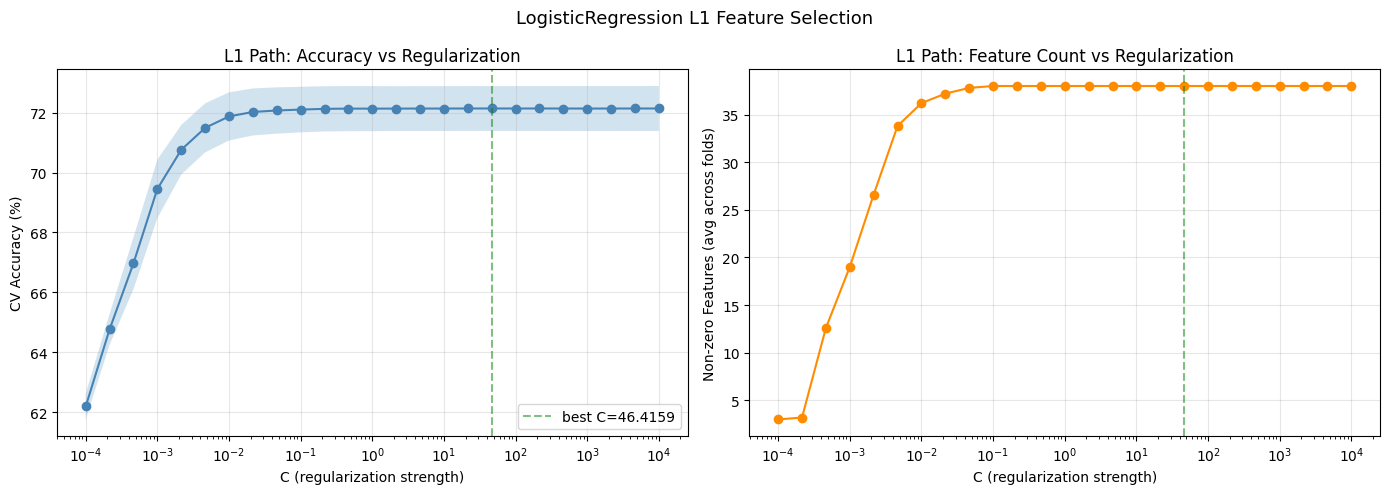

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs C (from LogisticRegressionCV scores)
axes[0].semilogx(C_values, mean_scores * 100, "o-", color="steelblue")
axes[0].fill_between(
    C_values,
    (mean_scores - std_scores) * 100,
    (mean_scores + std_scores) * 100,
    alpha=0.2,
)
axes[0].axvline(best_C, color="green", linestyle="--", alpha=0.5, label=f"best C={best_C:.4f}")
axes[0].set_xlabel("C (regularization strength)")
axes[0].set_ylabel("CV Accuracy (%)")
axes[0].set_title("L1 Path: Accuracy vs Regularization")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature count vs C — extract from coefs_paths_ (no refitting needed)
if hasattr(lr_cv, "coefs_paths_"):
    # coefs_paths_[class][fold] shape: (n_Cs, n_features)
    paths = lr_cv.coefs_paths_[1]  # class 1
    avg_n_features = [
        np.mean([np.sum(paths[fold][c_idx] != 0) for fold in range(len(paths))]) for c_idx in range(len(C_values))
    ]
else:
    # Fallback: count from the final refit
    avg_n_features = [np.sum(lr_cv.coef_[0] != 0)] * len(C_values)

axes[1].semilogx(C_values, avg_n_features, "o-", color="darkorange")
axes[1].axvline(best_C, color="green", linestyle="--", alpha=0.5)
axes[1].set_xlabel("C (regularization strength)")
axes[1].set_ylabel("Non-zero Features (avg across folds)")
axes[1].set_title("L1 Path: Feature Count vs Regularization")
axes[1].grid(alpha=0.3)

plt.suptitle("LogisticRegression L1 Feature Selection", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Stage 3: Stability Analysis

A feature selected in only 1 out of 5 folds is noise — it happened to help on that particular
split but doesn't generalize. A feature selected in 5/5 folds is genuine signal.

We take the features selected at the optimal C across all 5 folds, and keep only those
selected in ≥60% of folds (at least 3 out of 5).


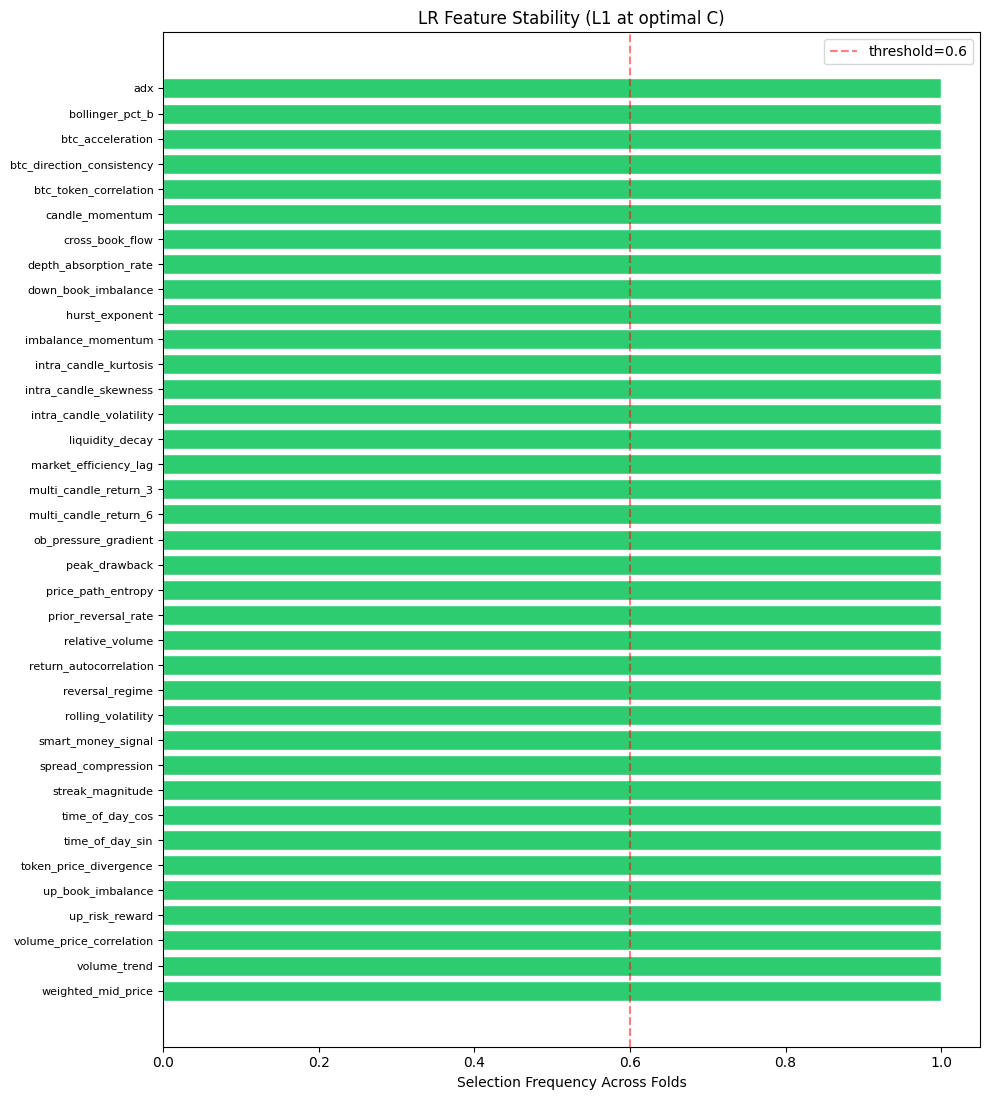


Stable features (selected in >=60% of folds): 37
  adx: 100%
  bollinger_pct_b: 100%
  btc_acceleration: 100%
  btc_direction_consistency: 100%
  btc_token_correlation: 100%
  candle_momentum: 100%
  cross_book_flow: 100%
  depth_absorption_rate: 100%
  down_book_imbalance: 100%
  hurst_exponent: 100%
  imbalance_momentum: 100%
  intra_candle_kurtosis: 100%
  intra_candle_skewness: 100%
  intra_candle_volatility: 100%
  liquidity_decay: 100%
  market_efficiency_lag: 100%
  multi_candle_return_3: 100%
  multi_candle_return_6: 100%
  ob_pressure_gradient: 100%
  peak_drawback: 100%
  price_path_entropy: 100%
  prior_reversal_rate: 100%
  relative_volume: 100%
  return_autocorrelation: 100%
  reversal_regime: 100%
  rolling_volatility: 100%
  smart_money_signal: 100%
  spread_compression: 100%
  streak_magnitude: 100%
  time_of_day_cos: 100%
  time_of_day_sin: 100%
  token_price_divergence: 100%
  up_book_imbalance: 100%
  up_risk_reward: 100%
  volume_price_correlation: 100%
  volume_tr

In [27]:
best_fold_feats = fold_selected_features

stable_features, stability_scores = feature_stability_report(
    best_fold_feats,
    decorr_features,
    threshold=0.6,
)

plot_stability(stability_scores, threshold=0.6, title="LR Feature Stability (L1 at optimal C)")

print(f"\nStable features (selected in >=60% of folds): {len(stable_features)}")
for f in stable_features:
    print(f"  {f}: {stability_scores[f] * 100:.0f}%")

## 5. Final cross-validated evaluation

In [28]:
accs, f1s, briers = [], [], []

for train_idx, val_idx in gkf.split(df, df["target"], groups=groups):
    X_train = df.iloc[train_idx][stable_features].values
    X_val = df.iloc[val_idx][stable_features].values
    y_train = df.iloc[train_idx]["target"].values
    y_val = df.iloc[val_idx]["target"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LogisticRegression(C=best_C, l1_ratio=1, solver="saga", max_iter=2000, random_state=42)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)

    accs.append(accuracy_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))
    briers.append(brier_score_loss(y_val, probs))

print(f"Final CV results with {len(stable_features)} stable features:")
print(f"  Accuracy: {np.mean(accs) * 100:.1f}% +/- {np.std(accs) * 100:.1f}%")
print(f"  F1:       {np.mean(f1s) * 100:.1f}% +/- {np.std(f1s) * 100:.1f}%")
print(f"  Brier:    {np.mean(briers):.4f} +/- {np.std(briers):.4f}")

/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Final CV results with 37 stable features:
  Accuracy: 72.2% +/- 0.7%
  F1:       74.7% +/- 1.1%
  Brier:    0.1768 +/- 0.0029


## 6. Save config

In [29]:
config = {
    "model": "logistic_regression",
    "features": stable_features,
    "n_features": len(stable_features),
    "accuracy_cv_mean": round(float(np.mean(accs)), 4),
    "accuracy_cv_std": round(float(np.std(accs)), 4),
    "f1_cv_mean": round(float(np.mean(f1s)), 4),
    "brier_cv_mean": round(float(np.mean(briers)), 4),
    "selection_method": "l1_regularization_path",
    "cv_folds": 5,
    "stability_threshold": 0.6,
    "feature_stability": {f: round(stability_scores[f], 2) for f in stable_features},
    "decorrelation_threshold": 0.7,
    "features_before_decorrelation": len(all_feat_cols),
    "features_after_decorrelation": len(decorr_features),
    "hyperparameters": {"C": round(float(best_C), 6), "l1_ratio": 1, "solver": "saga", "max_iter": 5000},
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_lr.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} LR features to {out_path}")
print(f"Features: {config['features']}")

Saved 37 LR features to ../../data/optimal_features_lr.json
Features: ['adx', 'bollinger_pct_b', 'btc_acceleration', 'btc_direction_consistency', 'btc_token_correlation', 'candle_momentum', 'cross_book_flow', 'depth_absorption_rate', 'down_book_imbalance', 'hurst_exponent', 'imbalance_momentum', 'intra_candle_kurtosis', 'intra_candle_skewness', 'intra_candle_volatility', 'liquidity_decay', 'market_efficiency_lag', 'multi_candle_return_3', 'multi_candle_return_6', 'ob_pressure_gradient', 'peak_drawback', 'price_path_entropy', 'prior_reversal_rate', 'relative_volume', 'return_autocorrelation', 'reversal_regime', 'rolling_volatility', 'smart_money_signal', 'spread_compression', 'streak_magnitude', 'time_of_day_cos', 'time_of_day_sin', 'token_price_divergence', 'up_book_imbalance', 'up_risk_reward', 'volume_price_correlation', 'volume_trend', 'weighted_mid_price']


## Conclusion

Feature selection pipeline:
1. **Decorrelation**: collapsed correlated features using Spearman clustering (|ρ| > 0.7)
2. **L1 path**: scanned 25 regularization strengths with GroupKFold(5) cross-validation
3. **Stability**: kept features selected in ≥60% of folds

Run `lr/02_export.ipynb` to export the model, then `lr/03_strategy.ipynb` for strategy discovery.
